In [10]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import corner
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# Get the current working directory
current_path = os.getcwd()
# Get the parent directory

parent_directory = os.path.abspath(os.path.join(current_path, os.pardir))
print("Parent Directory:", parent_directory)
sys.path.append(parent_directory)
from class_analysis import metrics_creator
from class_analysis import create_df_to_plot
from ssh_connect import ssh_che
from connect_CHE import download_data
from read_save import read_data
from class_analysis import graph_maker_1plot
from matplotlib.colors import LogNorm
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
from astropy import constants as C
from astropy import units as u
from ulens_params import event_param, microlensing_params
from detection_criteria import mag
import rubin_sim
import rubin_sim.maf as maf
from rubin_sim.data import get_baseline
from plot_hist import *
from ulens_params import *

Parent Directory: /home/anibal-pc/microlensing/simulation_Rubin/roman_rubin


In [11]:
data_TRILEGAL = pd.read_csv('../chunks_TRILEGAL_GENULENS/TRILEGAL_chunk_1.csv').iloc[0]
data_Genulens = pd.read_csv('../chunks_TRILEGAL_GENULENS/Genulens_chunk_1.csv').iloc[0]
system_type = "Planets_systems"


pars = event_param(0, data_TRILEGAL, 
            data_Genulens, system_type, 
            t0_range=[2460413.013828608, 2463335.013828608], 
            custom_system=None)

In [73]:
from astropy import units as u

100*u.M_sun.to("M_jup")

104756.55146604772

<>:24: SyntaxWarning: invalid escape sequence '\ '
<>:24: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_9270/3027847292.py:24: SyntaxWarning: invalid escape sequence '\ '
  plt.title("$DS = 8 kpc,\ M_1= 100 M_{\odot},\ M_2= 100M_{\odot}, semi-major \ axis = 0.1 AU $")


0.05540580275637938


Text(0.5, 1.0, '$DS = 8 kpc,\\ M_1= 100 M_{\\odot},\\ M_2= 100M_{\\odot}, semi-major \\ axis = 0.1 AU $')

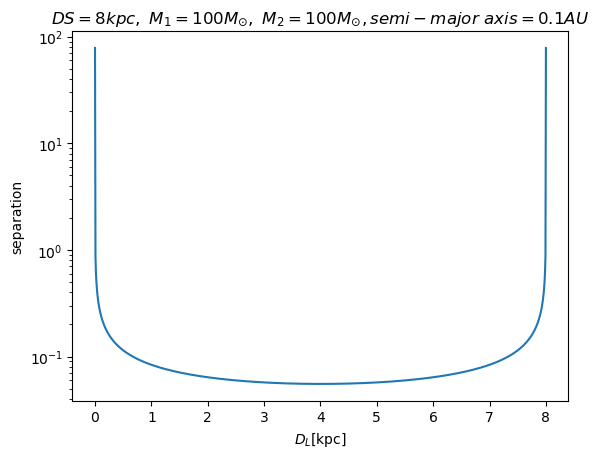

In [92]:
s = []
dl = np.linspace(1e-6,8-1e-6,1000)

for t in dl:
    name = 'test'
    orbital_period = 0
    semi_major_axis = 0.1
    DL = t
    star_mass = 100
    mass_planet =  104756.55146604772 
    DS = 8
    mu_rel = 1
    logTe = 1
    logL =1
    ulens_params = microlensing_params(name, orbital_period, semi_major_axis, DL, star_mass, mass_planet, DS, mu_rel, logTe, logL)
    
    s.append(ulens_params.s())
    
plt.plot(dl, s)
print(min(s))
plt.ylabel("separation")
plt.xlabel("$D_L$[kpc]")
plt.yscale("log")
plt.title("$DS = 8 kpc,\ M_1= 100 M_{\odot},\ M_2= 100M_{\odot}, semi-major \ axis = 0.1 AU $")

In [137]:
rho = []
thetas = []
thetaE = []
for t in dl:
    name = 'test'
    orbital_period = 0
    semi_major_axis = 0.1
    DL = t
    star_mass = 0
    mass_planet =  1
    DS = 8
    mu_rel = 1
    logTe = 3.5
    logL = -2.1
    ulens_params = microlensing_params(name, orbital_period, semi_major_axis, DL, star_mass, mass_planet, DS, mu_rel, logTe, logL)
    rho.append(ulens_params.rho())
    thetaE.append(ulens_params.theta_E().value)
    thetas.append(ulens_params.thetas().value)
    

print("source radius", ulens_params.source_radius())

source radius 0.2969293727548926 solRad


<>:1: SyntaxWarning: invalid escape sequence '\o'
<>:1: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_9270/4007115461.py:1: SyntaxWarning: invalid escape sequence '\o'
  plt.title("Source radius = 0.3 $R_{\odot}$, $M_L = 1M_{jup}$, $D_S = 8 kpc$")


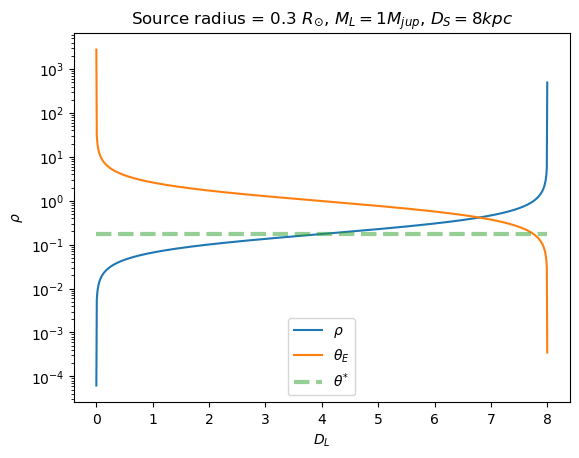

In [143]:
plt.title("Source radius = 0.3 $R_{\odot}$, $M_L = 1M_{jup}$, $D_S = 8 kpc$")
plt.plot(dl,rho,label=r'$\rho$')
plt.plot(dl, thetaE, label=r'$\theta_E$')
plt.plot(dl, thetas,linestyle = '--',alpha=0.5, linewidth=3, label=r'$\theta^{*}$')
plt.yscale("log")
plt.xlabel("$D_L$")
plt.ylabel(r"$\rho$")
plt.legend(loc='best')

In [100]:
# data_TRILEGAL